In [ ]:
print("KRITHIKA K - 24BAD061")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

KRITHIKA K - 24BAD061


In [ ]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


In [15]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to 1D
y_train = y_train.flatten()
y_test = y_test.flatten()

# Split training data into training and validation sets
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Testing samples:", len(x_test))


Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Training samples: 45000
Validation samples: 5000
Testing samples: 10000


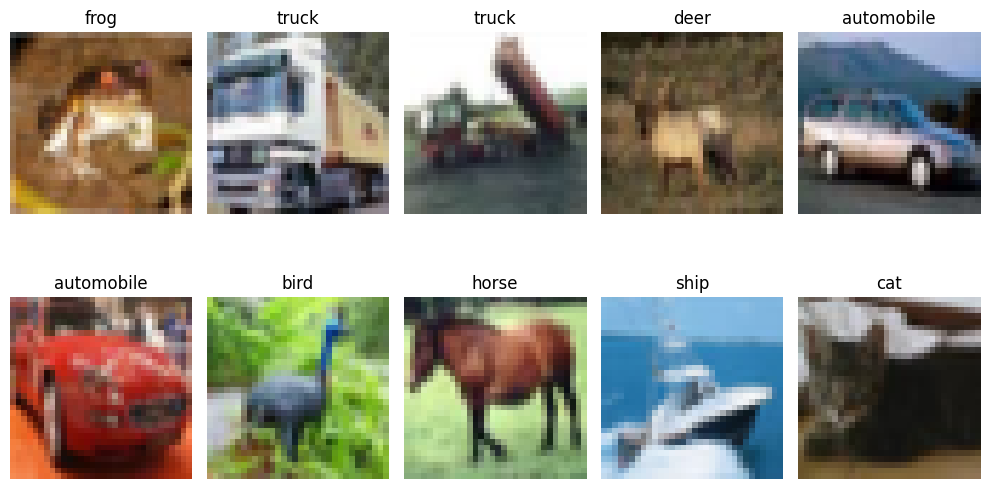

In [11]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
from tensorflow.keras import models, layers # Added import for models and layers

model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Softmax Output Layer
    layers.Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 74ms/step - accuracy: 0.4025 - loss: 1.6210 - val_accuracy: 0.5286 - val_loss: 1.3281
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.5518 - loss: 1.2620 - val_accuracy: 0.5768 - val_loss: 1.2033
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.6071 - loss: 1.1080 - val_accuracy: 0.6128 - val_loss: 1.0738
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.6451 - loss: 1.0131 - val_accuracy: 0.6396 - val_loss: 1.0318
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.6709 - loss: 0.9412 - val_accuracy: 0.6640 - val_loss: 0.9733
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6940 - loss: 0.8787 - val_accuracy: 0.6866 - val_loss: 0.9155
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.7097 - loss: 0.8283 - val_accuracy: 0.6962 - val_loss: 0.8785
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.7233 - loss: 0.7903 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\nTest Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)


In [ ]:
print("\nFinal Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Final Training Loss:",
      history.history['loss'][-1])

print("Final Validation Loss:",
      history.history['val_loss'][-1])


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


<Figure size 1000x800 with 0 Axes>

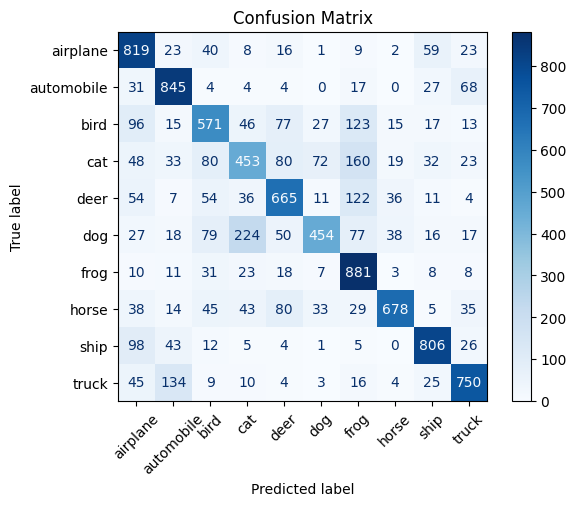

In [19]:
# Generate predictions
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()


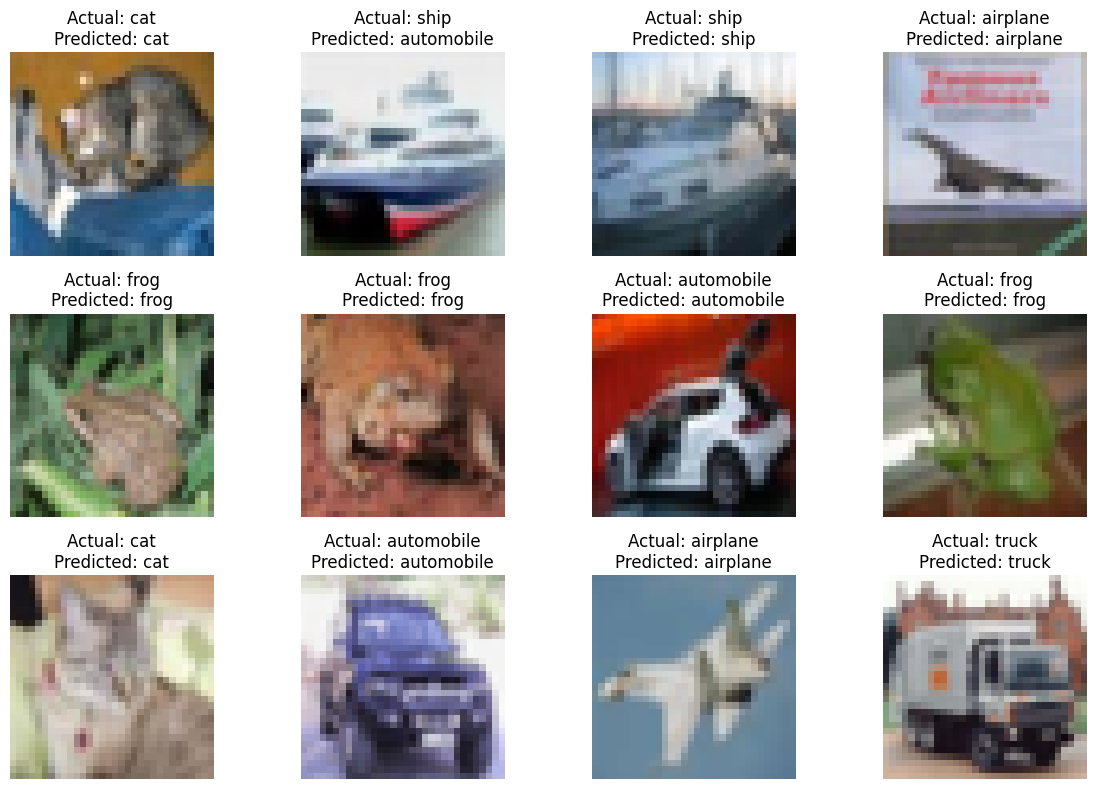

In [20]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    predicted_label = class_names[y_pred[i]]
    actual_label = class_names[y_test[i]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Number of misclassified images: 3078


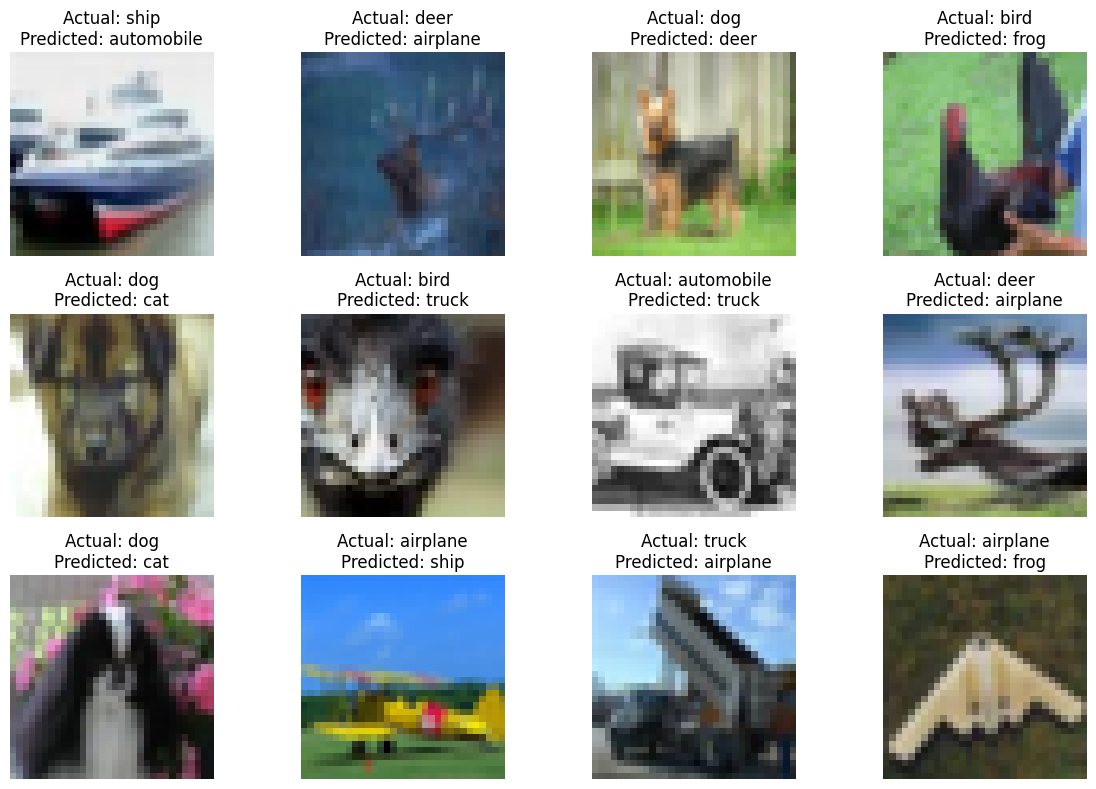

In [21]:
misclassified = np.where(y_pred != y_test)[0]

print("Number of misclassified images:", len(misclassified))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(misclassified))):

    index = misclassified[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[index])

    plt.title(
        f"Actual: {class_names[y_test[index]]}\n"
        f"Predicted: {class_names[y_pred[index]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()